In [142]:
from langgraph.graph import StateGraph , END 
from typing import TypedDict , Annotated , List
from langchain_core.messages import  HumanMessage , AnyMessage , SystemMessage , AIMessage
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent
from dotenv import load_dotenv
import os
import base64
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langchain.prompts import PromptTemplate
from operator import add
from langgraph.types import Command , interrupt

In [143]:
load_dotenv()

True

In [144]:
llm = ChatGoogleGenerativeAI(model=os.getenv("GOOGLE_MODEL"))
image_llm = ChatGoogleGenerativeAI(model="models/gemini-2.0-flash-preview-image-generation")

In [145]:
class agentState(TypedDict):
    query : str
    messages : Annotated[list[AnyMessage], add_messages] 
    agent_used : Annotated[list[str] , add]
    user_id : str
    human_feedback: Annotated[List[str] , add_messages]

In [146]:
thread_config = {"configurable": {
    "thread_id": "1234"
}}

In [147]:
router_prompt_template = """You are a multi-agent router responsible for selecting the best agent to handle the incoming user query. Choose the most suitable agent from the following options based on the task described in the query:

Available Agents:
- web_agent: Ideal for retrieving fresh, factual, or real-time information from the internet.
- llm_agent: Suitable for generating, transforming, or understanding text without needing live data.
- image_agent: Appropriate for generating visual content, such as illustrations, diagrams, or concept art.

Routing Logic:
1. If the query explicitly asks for an image, drawing, or visual representation, route to **image_gen_agent**.
2. If the query requests recent news, live events, or real-world facts, route to **web_search_agent**.
3. For all other cases, including creative writing, summarization, or general knowledge, route to **llm_search_agent**.

User Query:
{query}

Output Format:
Return only the most suitable agent name. If no agent is clearly suitable, default to **llm_agent**.
"""

router_prompt = PromptTemplate(template=router_prompt_template, input_variables=["query"])

In [148]:
from langchain_core.prompts import PromptTemplate

prompt = PromptTemplate(
    input_variables=["feedback", "query", "messages"],
    template="""
Evaluate the user's query to determine if it lacks clarity or is incomplete.

If additional context or refinement is needed, use the following:
- **Chat History**: {messages}
- **Human Feedback**: {feedback}

Then, generate a well-structured and contextually appropriate response that aligns with the user's intent.

**User Query**: {query}

Only refine or expand the query if necessary.
"""
)


image_prompt = PromptTemplate(
    input_variables=["feedback" , "query" , "messages"] , 
    template="""
    whenever the question looks like incomplete or need clarity 
    chat history : {messages} ,
    Humman Feedback : {feedback}
    generate a structure and well written response based on feedback and history 
    User query : {query}

    instruction:
    For final answer return only image path without any surrounding extras
    """
)


In [149]:
@tool
def humman_feedback(query):
    """Always use this tool before starting """
    print("[HUMAN IN LOOP CHAL RAHA HAIN]")
    user_feedback = interrupt({f"Add detail to your query {query}"})
    
    return user_feedback


In [150]:
@tool
def tavily_search_tool_func(query: str) -> str:
    """Search the web for up-to-date information."""
    return TavilySearch(max_results=5, topic="general").invoke(query)

web_search_agent = create_react_agent(model=llm, tools=[tavily_search_tool_func , humman_feedback], name="web_expert" , debug=True )

def web_agent(state:agentState) -> agentState:

    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )
    
    result = web_search_agent.invoke({
                "messages": [
                    {
                        "role": "user",
                        "content": prompt_formated
                    }
                ]
            })
    print(type(result) , "web")
    print(type(result["messages"][-1]) , "web_final")

    return {"messages" : [result["messages"][-1]]}


In [151]:
@tool
def llm_based_search_func(query: str) -> str:
    """Answer general knowledge queries using LLM."""
    return llm.invoke(query).content

llm_search_agent = create_react_agent(model=llm, tools=[llm_based_search_func , humman_feedback], name="llm_expert" , debug=True)

def llm_agent(state:agentState) -> agentState:

    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )


    result = llm_search_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": prompt_formated
                }
            ]
        })
    
    print(type(result) , "llm")
    print(type(result["messages"][-1]) , "llm_final")
    print("-----------------------------------")
    print(state["agent_used"])
    
    print(type(result["messages"][-1].content) , "llm_final")

    
    return {"messages" : [result["messages"][-1]]}
     


In [152]:
from pathlib import Path
import uuid

OUTPUT_DIR = Path("generated_images")
OUTPUT_DIR.mkdir(exist_ok=True)
@tool
def image_gen_func(query: str) -> str:
    """Generate image and return image path (not base64)."""
    enhanced_query = (
        "Create an image illustrating the following concept:\n\n"
        f"{query}\n\n"
        "All text in the image must be in English only. "
        "Avoid including foreign characters."
    )

    message = [HumanMessage(content=enhanced_query)]
    response = image_llm.invoke(
        message,
        generation_config={"response_modalities": ["TEXT", "IMAGE"]}
    )

    image_block = next(
        (block for block in response.content if isinstance(block, dict) and block.get("image_url")),
        None
    )

    if not image_block:
        return "ERROR: No image generated."

    # Decode base64 image content
    image_url = image_block["image_url"]["url"]
    if not image_url.startswith("data:image"):
        return "ERROR: Unexpected image format."

    image_base64 = image_url.split(",")[-1]
    try:
        image_bytes = base64.b64decode(image_base64)
    except base64.binascii.Error:
        return "ERROR: Failed to decode image."

    image_id = f"{uuid.uuid4().hex}.png"
    image_path = OUTPUT_DIR / image_id
    with open(image_path, "wb") as f:
        f.write(image_bytes)

    return str(image_path)



image_gen_agent = create_react_agent(model=llm, tools=[image_gen_func , humman_feedback], name="image_gen_expert" )

def image_agent(state:agentState) -> agentState:

    feedback = state["human_feedback"] if "human_feedback" in state else ["No feedback yey"]

    prompt_formated = image_prompt.format(
        feedback = feedback ,
        query = state["query"] ,
        messages = state["messages"],
    )
    
    print(state)
    result = image_gen_agent.invoke({
            "messages": [
                {
                    "role": "user",
                    "content": prompt_formated
                }
            ]
        })

    print("[THis]" , result)
    return {"messages": [result["messages"][-1]]} 



In [153]:
# result = image_gen_agent.invoke({
#         "messages": [
#             {
#                 "role": "user",
#                 "content": "Image of cat dancing"
#             }
#         ]
#     })

# print(result)

In [154]:
# import pprint
# pprint.pprint(result)

In [155]:
def end_node(state: agentState): 
    """ Final node """
    print("\n[end_node] Process finished")
    print("Final Generated Content:", state["messages"][-1])
    print("Final Human Feedback", state["human_feedback"])
    print("Final agent used" , state["agent_used"])
    return {"generated_post": state["messages"], "human_feedback": state["human_feedback"] , "agent_used" : state["agent_used"]}

In [156]:
def supervisor_node(state:agentState)->agentState:
    router_chain = router_prompt | llm
    result = router_chain.invoke({"query" : state["query"]})
    print(result.content)

    return {"agent_used": [result.content]}

    

In [157]:
def should_continue(state : agentState) -> agentState:

    if state["agent_used"][-1] == "llm_agent":
        return "llm_agent"
    elif state["agent_used"][-1] == "web_agent":
        return "web_agent"
    elif state["agent_used"][-1] == "image_agent":
        return "image_agent"
    
    else:
        return "llm_agent"

In [158]:
graph = StateGraph(agentState)

In [159]:
graph.set_entry_point("routing agent")

graph.add_node("routing agent" , supervisor_node)
graph.add_node("ending" , end_node)
graph.add_conditional_edges(
    "routing agent",
    should_continue,
    {
        "llm_agent" : "llm generation",
        "image_agent" : "image generation",
        "web_agent" : "web generation",

    }
)
graph.add_node("llm generation" , llm_agent)
graph.add_node("web generation" , web_agent)
graph.add_node("image generation" , image_agent)

graph.add_edge("llm generation" , END)
graph.add_edge("web generation" , END)
graph.add_edge("image generation" , END)


# graph.set_finish_point("routing agent")


In [160]:
from langgraph.checkpoint.memory import MemorySaver

In [161]:
checkpointer = MemorySaver()

In [162]:
app = graph.compile(checkpointer=checkpointer )

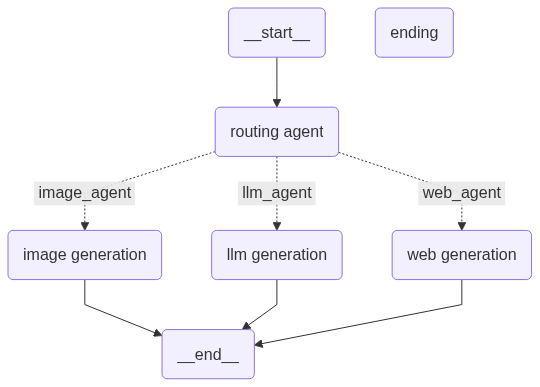

In [163]:
from IPython.display import display , Image
display(Image(app.get_graph().draw_mermaid_png()))

In [164]:
result = app.invoke({"query":" What is ai ??"  , "agent_used" : [] , "user_id" : "123"} , config=thread_config)

llm_agent
[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [{'content': '\n'
                          "Evaluate the user's query to determine if it lacks "
                          'clarity or is incomplete.\n'
                          '\n'
                          'If additional context or refinement is needed, use '
                          'the following:\n'
                          '- **Chat History**: []\n'
                          '- **Human Feedback**: []\n'
                          '\n'
                          'Then, generate a well-structured and contextually '
                          "appropriate response that aligns with the user's "
                          'intent.\n'
                          '\n'
                          '**User Query**:  What is ai ??\n'
                          '\n'
                          'Only refine or expand the query if necessary.\n',
               'ro

In [165]:
print(result)

{'query': ' What is ai ??', 'messages': [], 'agent_used': ['llm_agent'], 'user_id': '123', 'human_feedback': [], '__interrupt__': [Interrupt(value={'Add detail to your query The user is asking a very basic question about AI. I should use the llm_based_search_func to provide a definition of AI.'}, resumable=True, ns=['llm generation:89b0936a-e072-a64c-9eea-fb4a08e2549f', 'tools:e220f20b-2975-7be7-d925-307e670345d2'])]}


In [166]:
import pprint
pprint.pprint(result)

{'__interrupt__': [Interrupt(value={'Add detail to your query The user is '
                                    'asking a very basic question about AI. I '
                                    'should use the llm_based_search_func to '
                                    'provide a definition of AI.'},
                             resumable=True,
                             ns=['llm '
                                 'generation:89b0936a-e072-a64c-9eea-fb4a08e2549f',
                                 'tools:e220f20b-2975-7be7-d925-307e670345d2'])],
 'agent_used': ['llm_agent'],
 'human_feedback': [],
 'messages': [],
 'query': ' What is ai ??',
 'user_id': '123'}


In [167]:
snapshot  = app.get_state(config=thread_config)

In [168]:
pprint.pprint(snapshot.values)

{'agent_used': ['llm_agent'],
 'human_feedback': [],
 'messages': [],
 'query': ' What is ai ??',
 'user_id': '123'}


In [169]:
snapshot.metadata

{'source': 'loop',
 'writes': {'routing agent': {'agent_used': ['llm_agent']}},
 'step': 1,
 'parents': {},
 'thread_id': '1234'}

In [170]:
user_feedback = ""
while user_feedback != "done":
    user_feedback = input("Provide feedback (or type 'done' when finished): ")

    if user_feedback.lower() != "done":
        resumed_result = app.invoke(
            Command(resume=user_feedback) , config=thread_config
        )
        import pprint
        pprint.pprint(resumed_result)

[2:tasks] Starting 1 task for step 2:
- tools -> [{'args': {'query': 'The user is asking a very basic question about AI. I '
                    'should use the llm_based_search_func to provide a '
                    'definition of AI.'},
  'id': '1da6b391-4f5e-484e-95e8-44bfd55a2201',
  'name': 'humman_feedback',
  'type': 'tool_call'}]
[HUMAN IN LOOP CHAL RAHA HAIN]
[2:writes] Finished step 2 with writes to 1 channel:
- messages -> [ToolMessage(content='answer for ai in stock market', name='humman_feedback', tool_call_id='1da6b391-4f5e-484e-95e8-44bfd55a2201')]
[2:checkpoint] State at the end of step 2:
{'messages': [HumanMessage(content="\nEvaluate the user's query to determine if it lacks clarity or is incomplete.\n\nIf additional context or refinement is needed, use the following:\n- **Chat History**: []\n- **Human Feedback**: []\n\nThen, generate a well-structured and contextually appropriate response that aligns with the user's intent.\n\n**User Query**:  What is ai ??\n\nOnly 

In [171]:
from PIL import Image

if result["__interrupt__"]:
    user_feedback = ""    # Initialize before loop

    while user_feedback.lower() != "done":
        print("ENTERING RESUME")
        user_feedback = input("Provide feedback (or type 'done' when finished): ")
        print(user_feedback)
        if user_feedback.lower()!= "done":
            resumed_result = app.invoke(Command(resume=user_feedback), config=thread_config)
            
            if resumed_result["agent_used"][-1] == "image_agent":
                image_path = resumed_result["messages"][-1].content 

                img = Image.open(image_path)
                img.show()
                # continue

            print("------------------")
            print("EXITING RESUME")

            import pprint
            pprint.pprint(resumed_result)

ENTERING RESUME
done


In [172]:
pprint.pprint(app.get_state(config=thread_config))

StateSnapshot(values={'query': ' What is ai ??', 'messages': [AIMessage(content='AI, or Artificial Intelligence, is a broad field of computer science focused on creating machines capable of performing tasks that typically require human intelligence. This involves enabling computers to learn, reason, solve problems, understand language, and perceive their environment.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, name='llm_expert', id='run--8316b4eb-fb39-4324-8db4-e365647c77c9-0', usage_metadata={'input_tokens': 1091, 'output_tokens': 48, 'total_tokens': 1139, 'input_token_details': {'cache_read': 0}})], 'agent_used': ['llm_agent'], 'user_id': '123', 'human_feedback': []}, next=(), config={'configurable': {'thread_id': '1234', 'checkpoint_ns': '', 'checkpoint_id': '1f042e54-2440-6062-8002-0df8014d2f90'}}, metadata={'source': 'loop', 'writes': {'llm